In [1]:
import sys
path_lock = False
if not path_lock:
    sys.path.append("../")
    path_lock = True
    
import numpy as np
import ffiting as ff

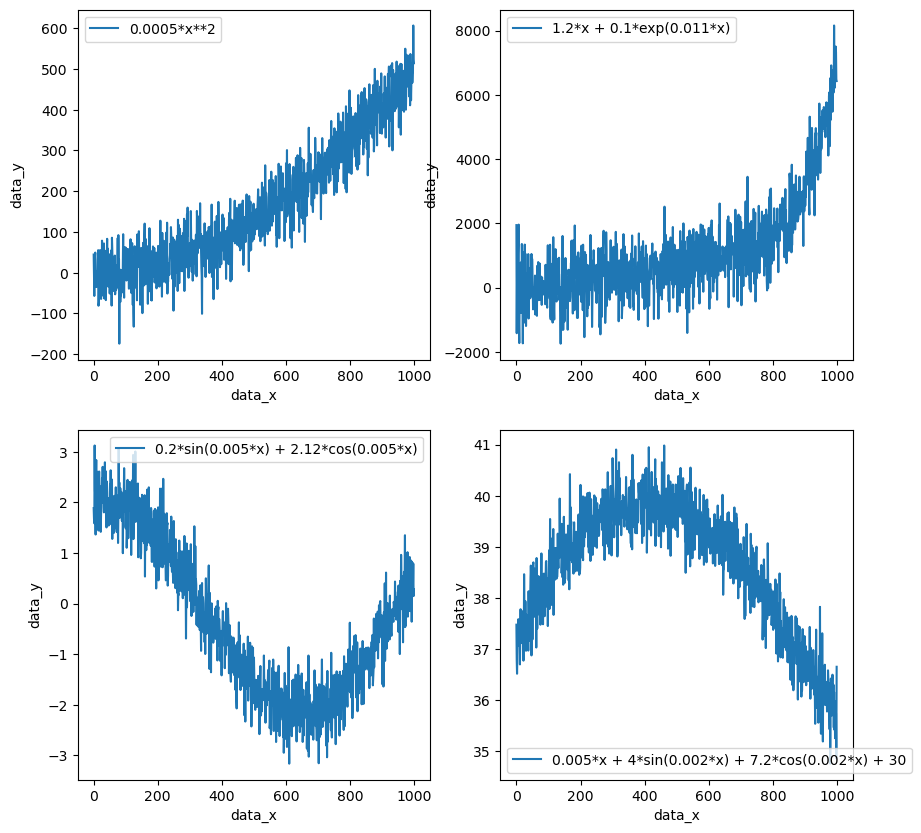

In [2]:
data_x: np.ndarray = np.arange(0, 1000)

poly_md = ff.Generators.ranked_poly([0, 0, 0.0005])
exp_md = ff.Generators.exponential([0, 1.2, 0.1, 0.011])
trans_md = ff.Generators.transcendental([0.2, 0.005, 2.12])
lint_md = ff.Generators.combined_lint([30, 0.005, 4, 0.002, 7.2, 0.01])

data_poly_train = ff.apply_noise(poly_md(data_x))
data_exp_train = ff.apply_noise(exp_md(data_x))
data_trans_train = ff.apply_noise(trans_md(data_x))
data_lint_train = ff.apply_noise(lint_md(data_x))

ff.sep_plot(
    ff.PlotRequest(data_poly_train, poly_md.label),
    ff.PlotRequest(data_exp_train, exp_md.label),
    ff.PlotRequest(data_trans_train, trans_md.label),
    ff.PlotRequest(data_lint_train, lint_md.label),
)

Model rank was raised to 3


'Polynomial generated:'

c0 + c1*x + c2*x**2

'Coeffs: [ 2.52919312e-09  4.81845720e-04  1.74452789e-02 -1.46615914e+00]'

'Metrics:'

Residual SE: 181.682
Mean SE: 32942.498
Linear Div: 139452.718
Standard Div: 36.583
Standard Err: 1.157
Determination Coeff: -23.615
Correlation Coeff: 0.919
Concordance Coeff: 0.000


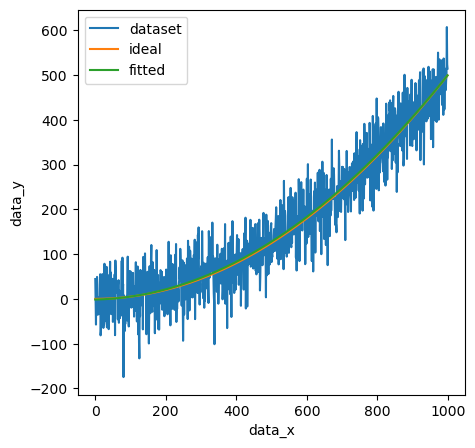

In [7]:
poly_m = ff.Models.ranked_poly(4)
poly_m.options.raise_rank = True
poly_fitted = poly_m.fit(data_poly_train)

display("Polynomial generated:", poly_m.expr_sp)
display(f"Coeffs: {poly_fitted.coeffs}")

display("Metrics:")
data_poly_ideal = poly_md(data_x)
print(ff.get_metrics(poly_m, data_origin=data_poly_ideal))

ff.multi_plot(
    ff.PlotRequest(data_poly_train, "dataset"),
    ff.PlotRequest(data_poly_ideal, "ideal"),
    ff.PlotRequest(poly_fitted(data_x), "fitted"),
)